# Predicting the Ocean Surface Boundary Layer's Density Profiles using Observational Data 


### Group 7: Azam Khan, Samuel Kortchmar, Ahinoam Toubia

In this project, our group apply the same methodology from the paper *Sane et al. (2023) "Parameterizing vertical mixing coefficients in the ocean surface boundary layer using neural networks."*
to estimate density profiles using observational data from Papa Station (Located in the North Pacific Ocean, 50° North latitude, 145° West longitude) and analyze the effects of seasonality on the dataset.

**About Papa Station**: Papa Station is a long-term oceanic monitoring site located in the Northeast Pacific Ocean (50°N, 145°W). It has been an important observation site for oceanographic and climate research since the 1950s. The Papa Station mooring, maintained by NOAA’s Pacific Marine Environmental Laboratory (PMEL) and partners, provides real-time data on oceanographic and atmospheric conditions (such as sea surface temperature, salinity, air temperature, and wind speed). The mooring data are publicly available through the NOAA PMEL Ocean Climate Stations (OCS) data portal ([link](https://www.pmel.noaa.gov/ocs/data/disdel/)), where users can access quality-controlled datasets for scientific research, modeling, and climate assessments.

### Tasks Addressed:
- **Data Processing and Preparation**: Acquire and clean data from Papa Station as well as reading and filtering the Generalized Ocean Turbulence Model (GOTM) output.
- **Identify the depths of the mixed layer**: Determine the mixed layer depths (MLD), h, from Papa Station Mooring Data.
- **Neural Network Training**: Implementing neural networks to predict the density / diffusivity based on observational data as well as creating a NN which takes as inputs SST, SSS, time [0-365] to predict the density profil.
- **Model Evaluation and Visualization**: Evaluate the model's performance using metrics such as training and validation loss, and present the results visually.
- **Paper vs. observational data**: Examine the relationship between observational data variables and the input variables used in the paper.
- **Seasonality**: Explain the effects of seasonality on GOTM simulations vs. observational data.

### Research Question: Apply the methodology from the paper to estimate density profiles from observational data and examine the influence of seasonality.

#### Import Modules and load files

In [ ]:
%%capture
import importlib

# Check and install torch
if importlib.util.find_spec("torch") is None:
    !pip install torch

# Check and install zarr
if importlib.util.find_spec("zarr") is None:
    !pip install zarr

# Ensure xarray is upgraded
!pip install --upgrade xarray

In [1]:
# code
from utils import (
    load_cdf_files,
    plot_invalid_values,
    filter_valid_timesteps,
    merge_and_prepare_datasets,
    plot_variable_histograms,
    plot_dp_distributions,
    plot_correlation_heatmap,
    create_density_profile_filled,
    preprocess_train_valid_data,
    learnKappa_layers,
    modeltrain_loss,
    plot_training_validation_loss,
    plot_density_profile,
    performance_sigma_point,
    prepare_data_pipeline,
    run_hyperparameter_sweep,
    create_highlighted_df
)
from pprint import pprint
import determine_mld

/Users/azamkhan/anaconda3/envs/nasa/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# code
dss = load_cdf_files("data/papa_observational_data/")
print("List of observational variables from PAPA Mooring Station:\n")
pprint(list(dss.keys()))

List of observational variables from PAPA Mooring Station:

['temperature_profile',
 'longwave_radiation',
 'air_temperature',
 'possition_lon_lat',
 'shortwave_radiation',
 'sea_surface_salinity',
 'sea_surface_temperature',
 'barometric_pressure',
 'wind_speed_profile',
 'rain',
 'density_profile',
 'salinity_profile']


# Data Processing and Preparation


## Data Quality Codes

The observational data is reported with different layers of quality, ranging from 0-5:
- 0: **missing**
- 1: **highest**
- 2: **default**
- 3: **adjusted**
- 4: **lower**
- 5: **sensor failure**

We decided to accept points of "highest" (1), "default" (2) and "adjusted" (3) quality. When columns were more than 3/4 missing, we fully omitted them. For columns with _some_ missing or poor quality data, we used stepwise interpolation to fill in the values.

Quality data for temperature (from _pyncview_) between 2008-2024:
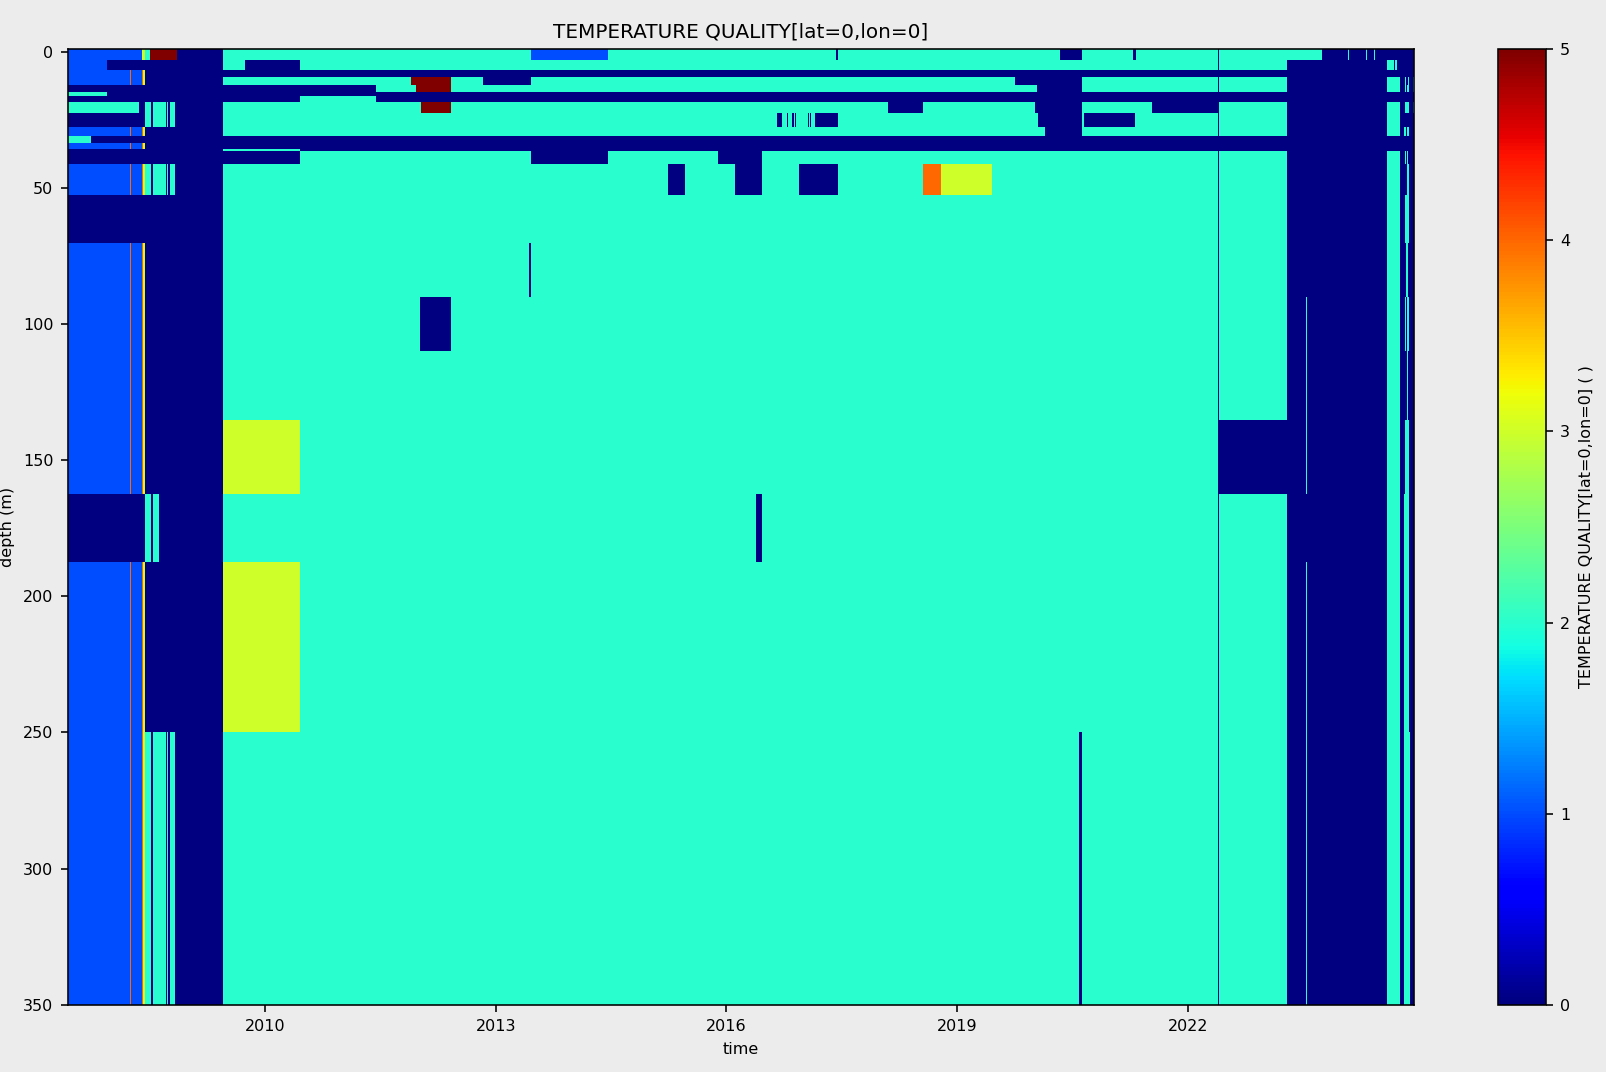
____________

Quality data for density (from _pyncview_) between 2008-2024:
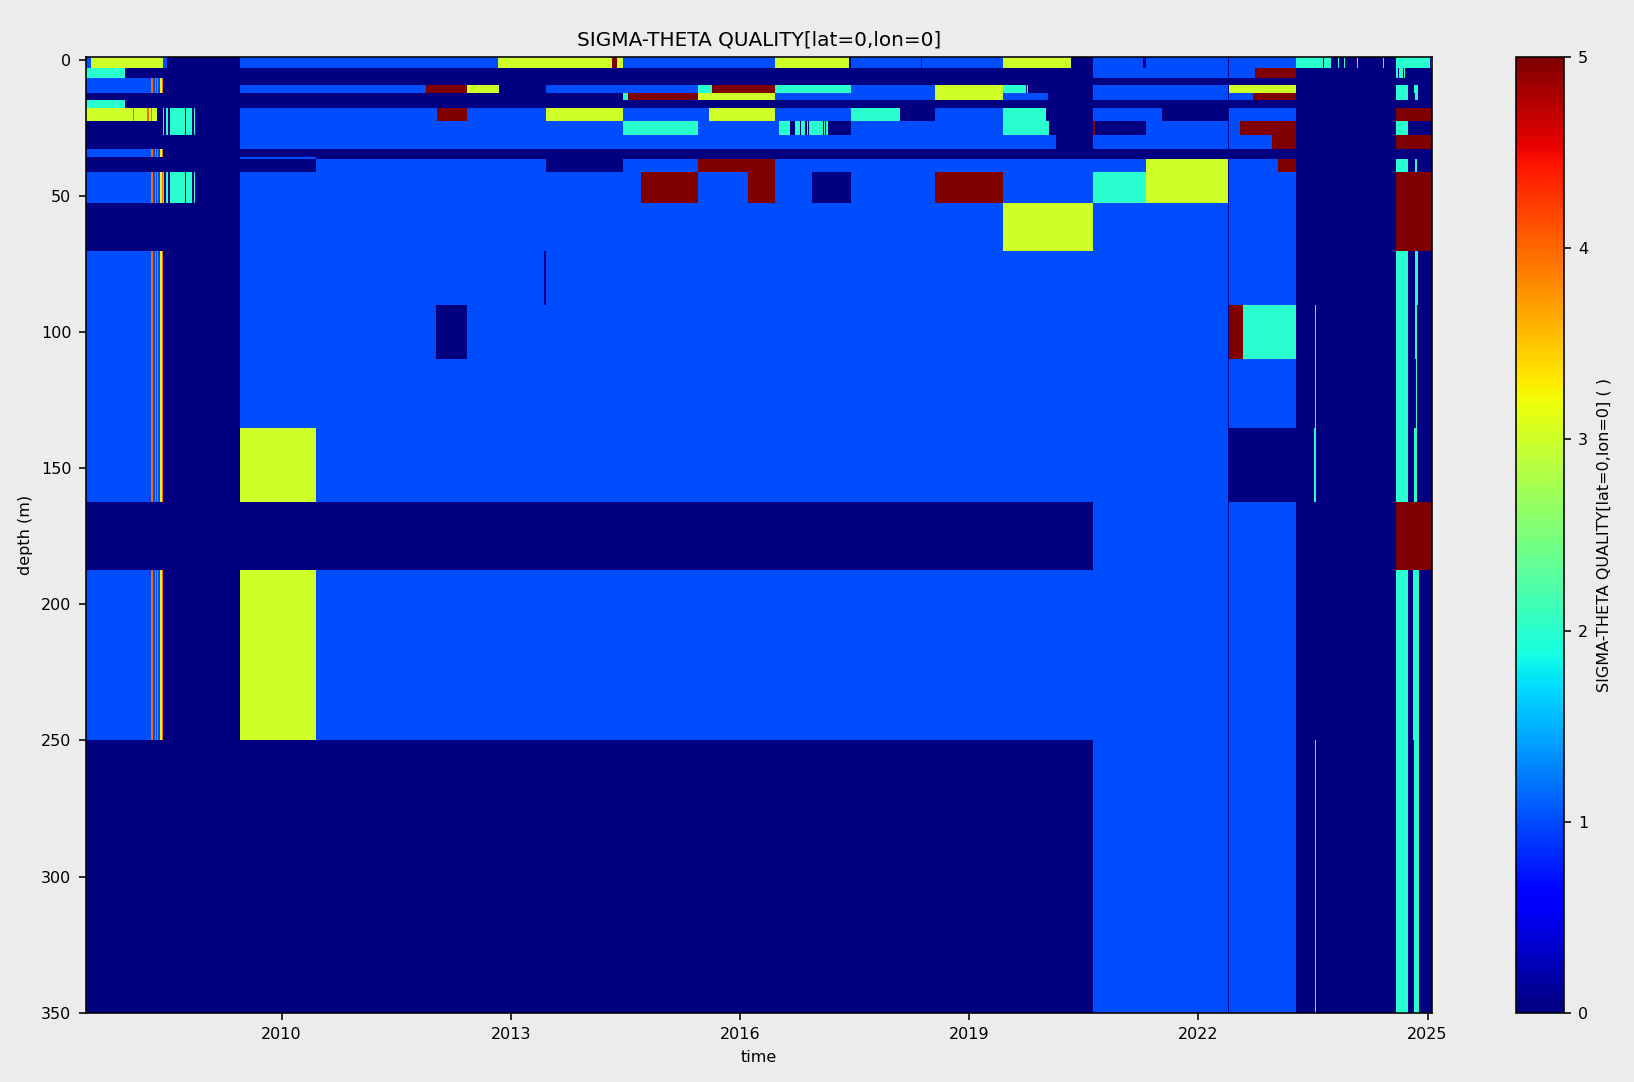
____________

The density value is not measured directly, but is computed from temperature and ocean conductivity. You can see in these plots that quality issues in the temperature data are forwarded onto the density plot.



## Visualizing Cleaned Profiles and Mixed Layer Depth

Once the data is cleaned, we can visualize it. Our group wanted to illustrate the Mixed Layer Depth (MLD) to understand how it changes over time. The mixed layer can be understood as a region of homogenous water, so we attempt to compute its boundary with thresholding.

$$ |\rho(z) - \rho_{surface}| > 0.03kg/m^3  $$
$$ |T(z) - T_{surface}| > 0.2C°  $$


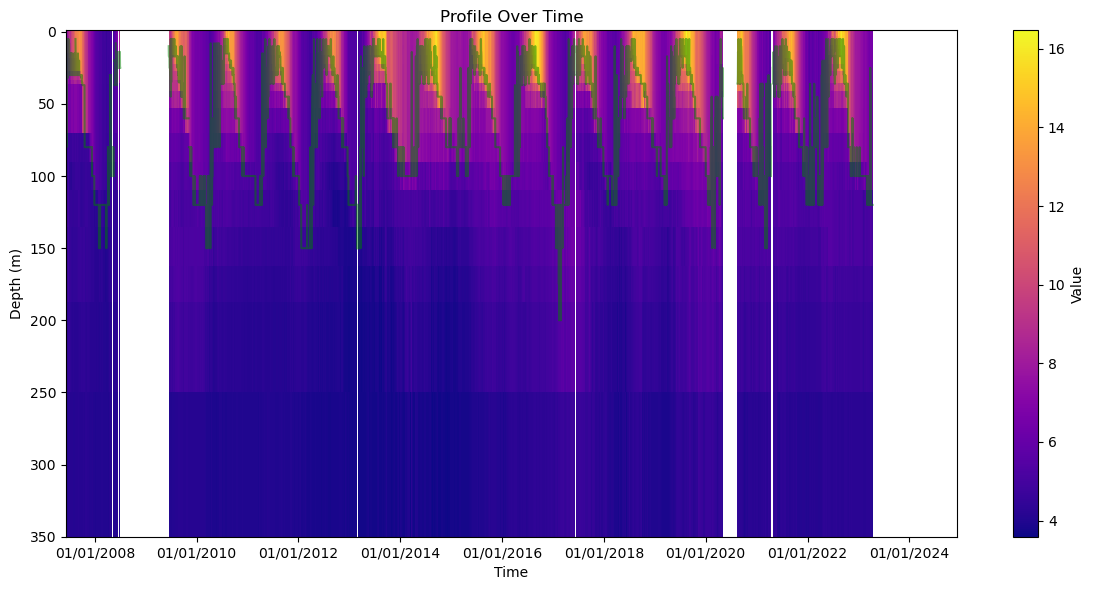

In [3]:
from determine_mld import plot_mld
_, temperature_based_mld = plot_mld('temperature_papa')


**Graph 1** depicts seasonal variations in temperature (ranging from yellow to purple) and mixed layer depth (shown in green) over time. During winter, temperatures are lower (purple), and the mixed layer deepens, whereas in summer, temperatures rise (yellow), and the mixed layer becomes shallower. This graph is based on pure observetional data from Papa Station.

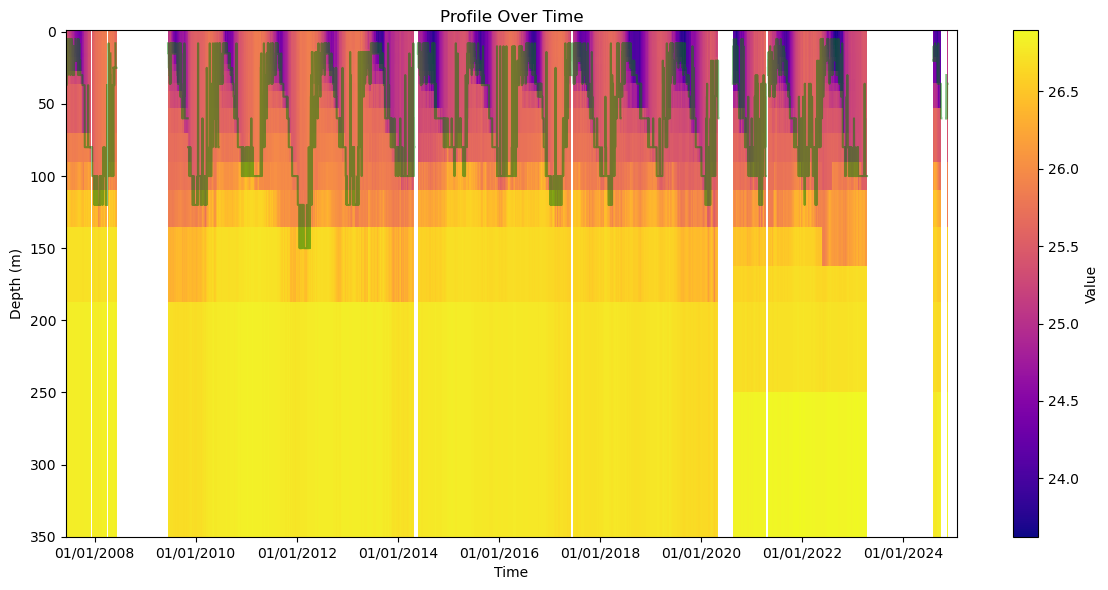

In [4]:
# code
_, density_based_mld = plot_mld('density_papa')

**Graph 2** depicts seasonal variations in density (ranging from yellow to purple) and mixed layer depth (shown in green) over time. During winter, the density gets higher (orange-yellow), and the mixed layer deepens, whereas in summer, density gets lower (purple), and the mixed layer becomes shallower. This graph is based on pure observetional data from Papa Station.

## Mixed Layer Depth Seasonality

Next, we compared the derived MLD values against each other and on a yearly basis. Additionally, we explored running our own GOTM simulation using meteorological forcing data from Papa station.

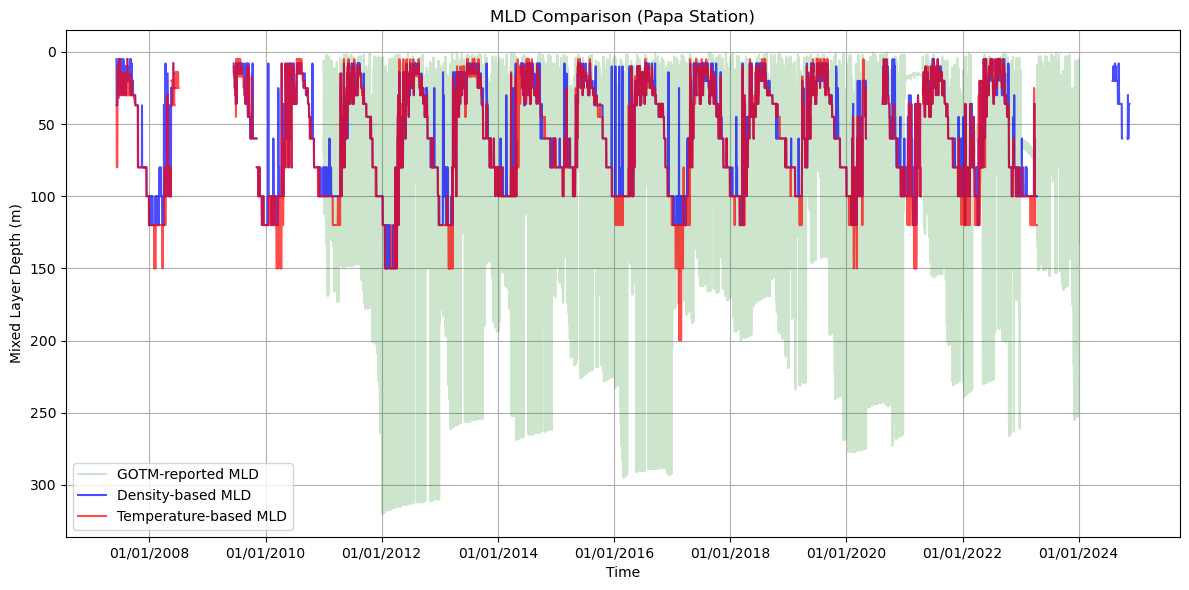

In [5]:
# code
from determine_mld import plot_mld_comparison

plot_mld_comparison(density_based_mld, temperature_based_mld)

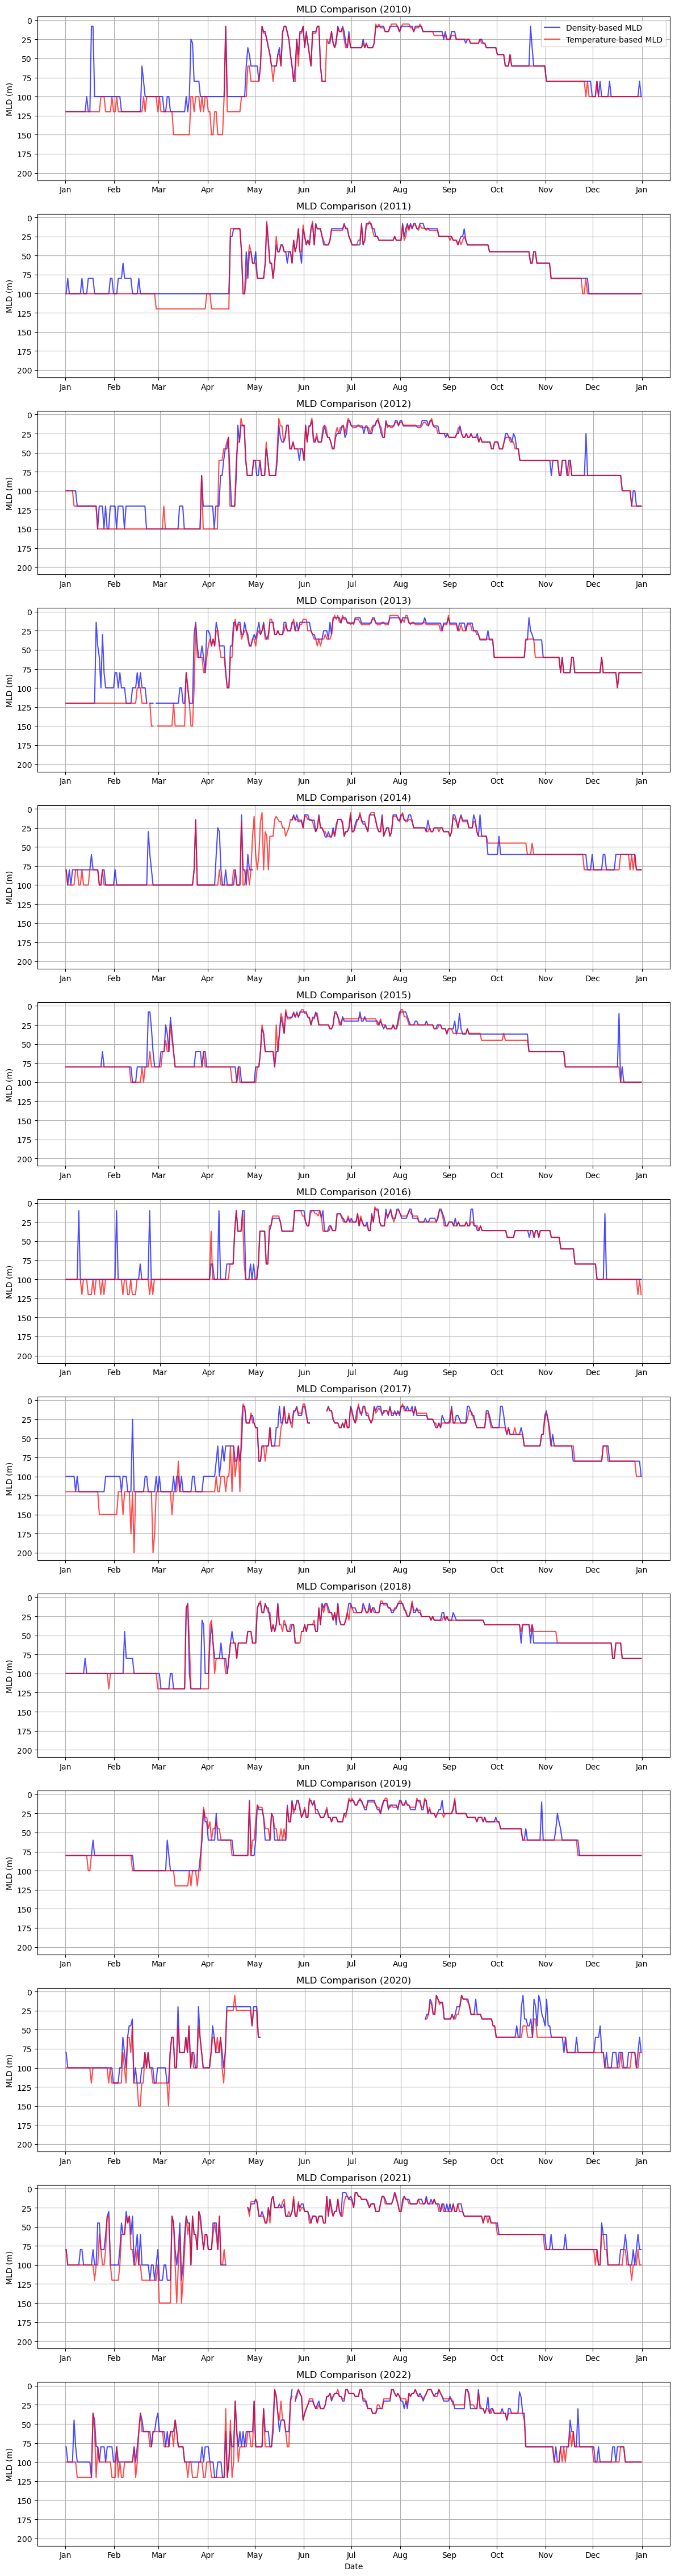

In [6]:
# code
from determine_mld import plot_mld_comparison_by_year

plot_mld_comparison_by_year(density_based_mld, temperature_based_mld)

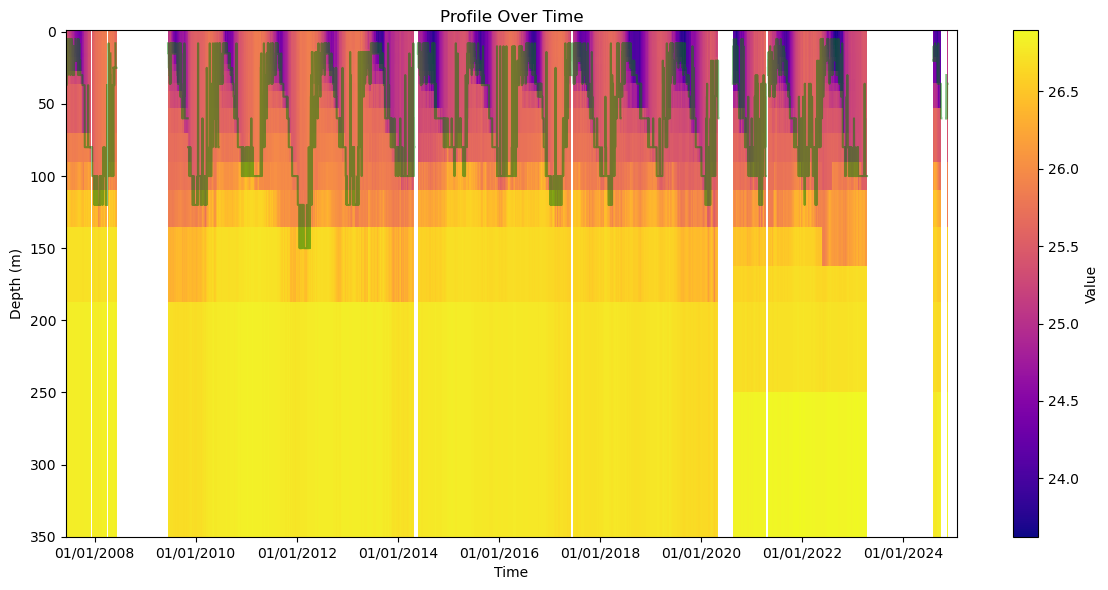

In [7]:
# code
temp = filter_valid_timesteps(dss, "sea_surface_temperature", "QT_5025", "T_25")
sst = filter_valid_timesteps(dss, "sea_surface_salinity", "QS_5041", "S_41")
profiles, _ = determine_mld.plot_mld("density_papa")
filled_profiles = create_density_profile_filled(profiles, dss)

In [8]:
# code
full_df = merge_and_prepare_datasets(
    [(temp, ["time", "T_25"]), (sst, ["time", "S_41"])],
    filled_profiles,
    ["time"],
    ["time", "T_25", "S_41"],
)

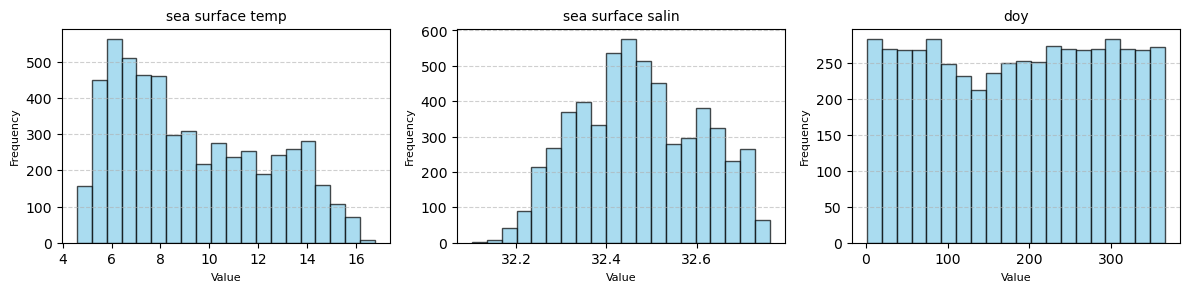

In [9]:
# code
variables = {
    "sea surface temp": temp.values.flatten(),
    "sea surface salin": sst.values.flatten(),
    "doy": full_df["doy"].values.flatten(),
}

plot_variable_histograms(variables)

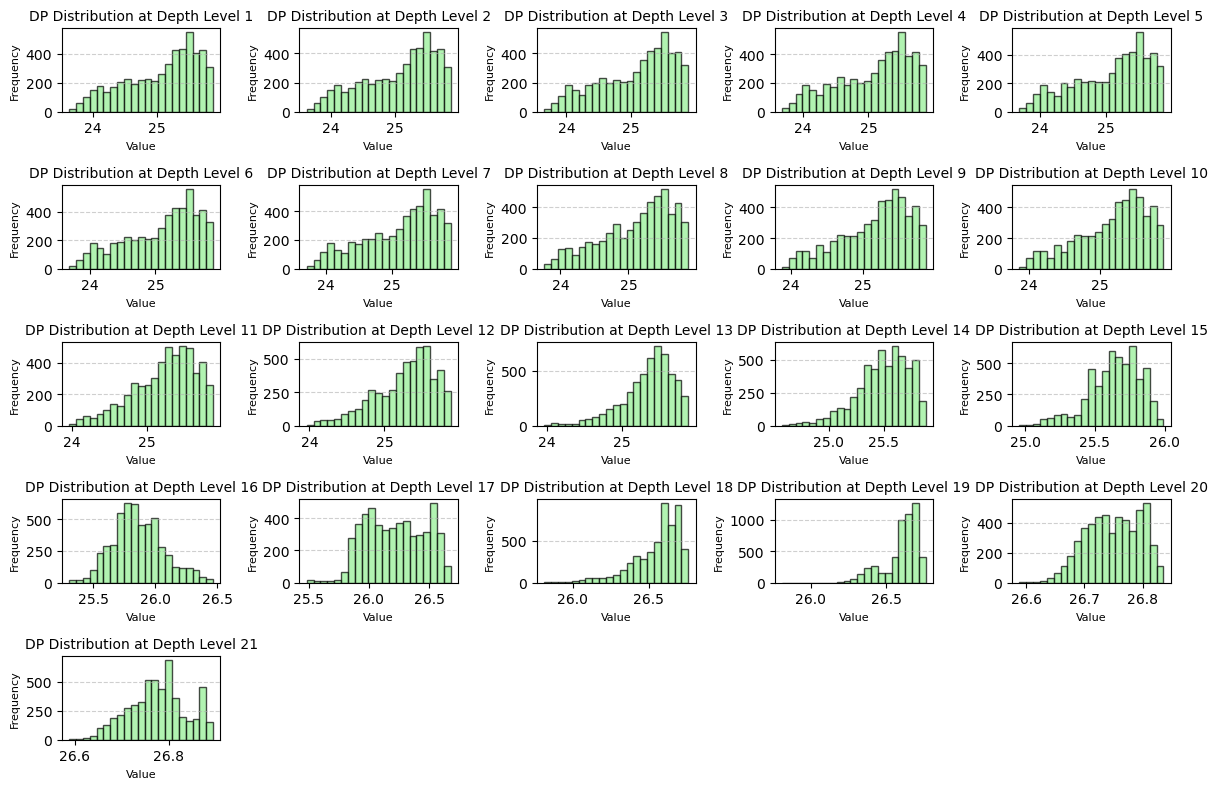

In [10]:
plot_dp_distributions(full_df)

- **Graph 3**: The plots processes and visualizes data from Papa Station for the variables wind speed, sea surface temperature, sea surface salinity, and day of the year (doy). The plots show the distribution of each variable's values, with bins representing the frequency of occurrences.

In [11]:
# code

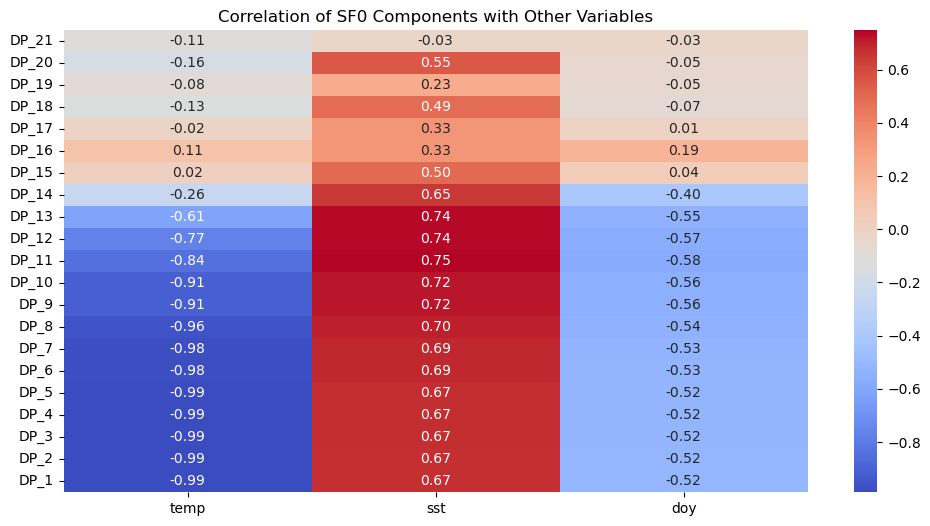

In [12]:
# code
data = {
    "temp": full_df["T_25"].values.flatten(),
    "sst": full_df["S_41"].values.flatten(),
    "doy": full_df["doy"].values.flatten(),
}

plot_correlation_heatmap(full_df, data)

- **Graph 4**:  A heatmap that visualizes the correlation between wind speed (ws), sea surface temperature (sst), temperature (temp), and day of year (doy), along with other environmental variables.

In [13]:
# code
import copy as copy

variables = [
    {"name": "T_25", "type": "static"},
    {"name": "S_41", "type": "static"},
    {"name": "doy", "type": "static"},
    {"name": "DP_21", "type": "dp"},  # Will use default DP config
]
data_load_main = prepare_data_pipeline(full_df, variables)
data_load3 = copy.deepcopy(data_load_main)

data, x, y, stats, k_mean, k_std, valid_x, valid_y, maxes = preprocess_train_valid_data(
    data_load3
)

In [14]:
# code
import torch
print("Training Set Size:", len(x))
print("Validation Set Size:", len(valid_x))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Convert to PyTorch tensors and move to device
x = torch.tensor(x, dtype=torch.float32).to(device)
y = torch.tensor(y, dtype=torch.float32).to(device)
valid_x = torch.tensor(valid_x, dtype=torch.float32).to(device)
valid_y = torch.tensor(valid_y, dtype=torch.float32).to(device)


Training Set Size: 4192
Validation Set Size: 1048


In [15]:
# Train N1 for the first time!
epochs, k_points, lr = 5000, 21, 1e-02
in_nod, hid_nod, o_nod = 3, 32, 21

torch.manual_seed(10)

k_mean_c = torch.tensor(k_mean).float().to(device)
k_std_c = torch.tensor(k_std).float().to(device)

model = learnKappa_layers(in_nod, hid_nod, o_nod)
model = model.to(device)
model, loss_array = modeltrain_loss(in_nod,hid_nod,o_nod,lr,epochs,x,y,valid_x,valid_y,model,device,k_mean_c,k_std_c,patience=1000,
)


Training Progress:  29%|██▉       | 1445/5000 [00:08<00:21, 161.72epoch/s, patience_count=999, train_loss=0.00321, valid_loss=0.00608]


Early stopping at epoch 1445. Validation loss has not improved for 1000 epochs.


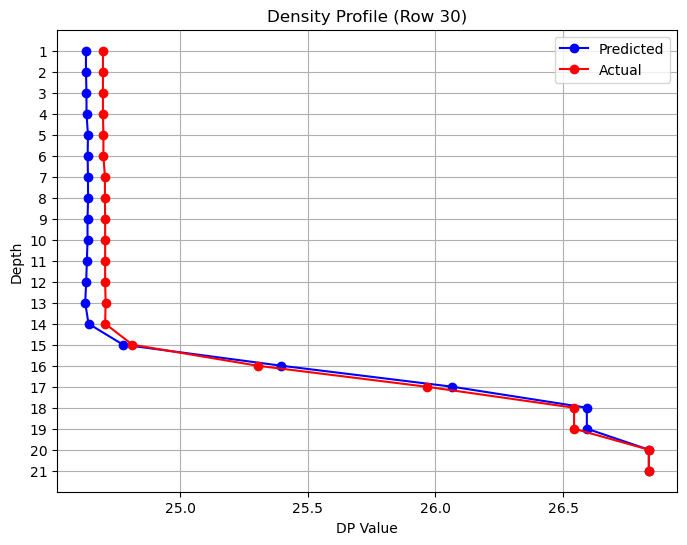

In [16]:
plot_density_profile(
    30,
    model(valid_x[30]).detach().numpy(),
    valid_y[30].detach().numpy(),
    k_std,
    k_mean,
    maxes,
)

- **Graph 5**: The graph was generated by using neural network training to predict the next density profile, based on temperature, salinity, and time. The plot shows the predicted vs. actual density profile (DP) values for a given depth in the dataset. The depth is shown on the y-axis (increasing depth downward). The DP values are plotted on the x-axis, with the predicted values in blue and the actual values in red. 

In [17]:
# code

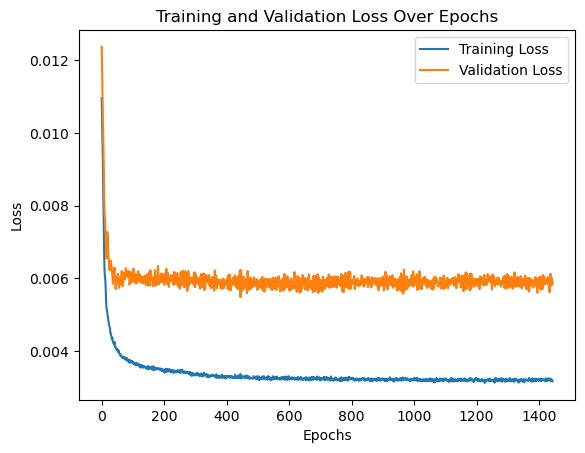

In [18]:
# code
plot_training_validation_loss(loss_array)

- **Graph 6**: The plot shows the training loss and validation loss over multiple epochs during the training of the NN model. The x-axis represents the number of epochs (iterations) during training while the y-axis represents the loss values, which measure the difference between the predicted output and the actual target for each example in the dataset.  

In [19]:
# code

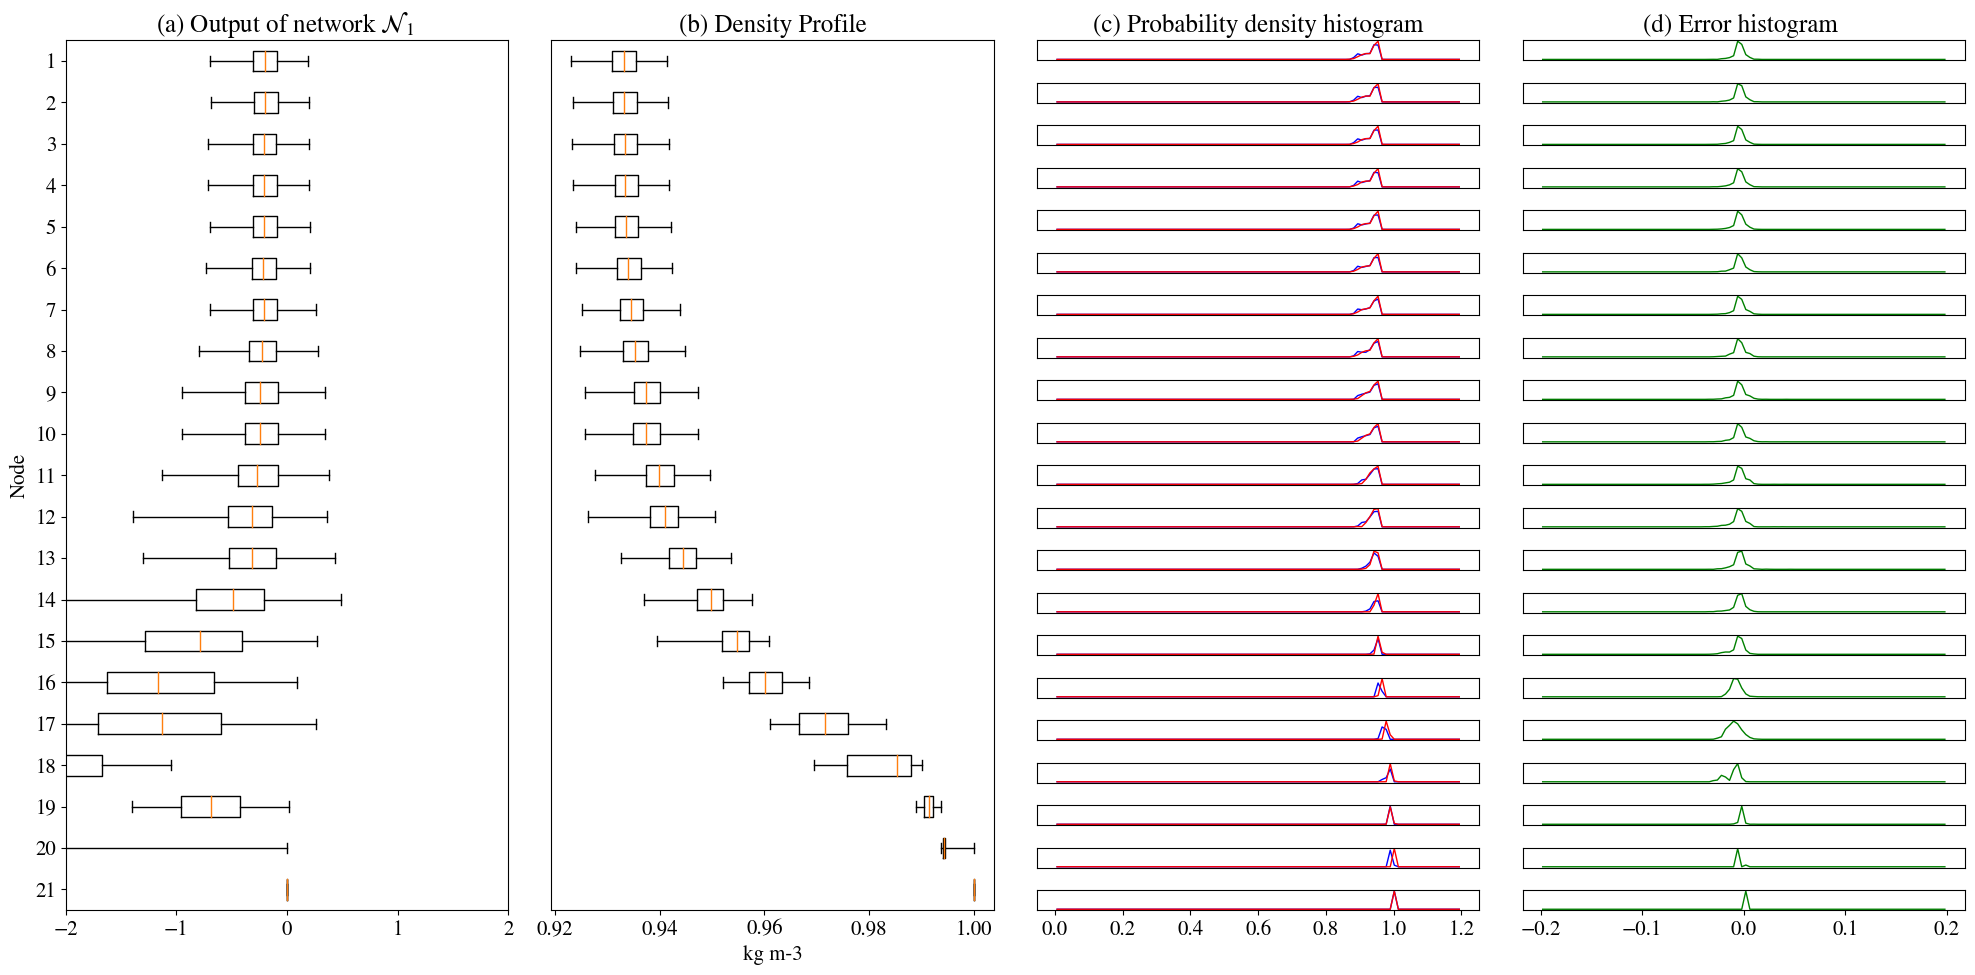

In [20]:
# code
performance_sigma_point(
    model,
    x,
    valid_x,
    y,
    valid_y,
    k_mean,
    k_std,
    maxes,
)

- **Graph 7**: The graphs visualize the performance of a neural network model by plotting output differences, density profiles, and probability and error histograms. From left to right- Network Output Differences show how the predicted and actual outputs differ for each node in the network. The Density Profile predicts the next density profile implementing neural networks which takes as inputs SST, SSS, time [0-365]. Probability Density Histograms show the distribution of the model's predictions compared to the actual values. Error Histograms show the distribution of the errors between the predicted and actual values.

# Hyperparameter Tuning

In [21]:
# code
hyperparameters_table = run_hyperparameter_sweep(
    k_mean, k_std, x, y, valid_x, valid_y, device
)

la, h, lr is > 1 16 0.1


Training Progress:  57%|█████▋    | 1717/3000 [00:06<00:04, 261.09epoch/s, patience_count=999, train_loss=0.00387, valid_loss=0.00623]



Early stopping at epoch 1717. Validation loss has not improved for 1000 epochs.
la, h, lr is > 1 16 0.01


Training Progress:  35%|███▌      | 1062/3000 [00:04<00:07, 249.95epoch/s, patience_count=999, train_loss=0.00361, valid_loss=0.00604]



Early stopping at epoch 1062. Validation loss has not improved for 1000 epochs.
la, h, lr is > 1 16 0.001


...


Early stopping at epoch 1005. Validation loss has not improved for 1000 epochs.
la, h, lr is > 3 64 0.01


Training Progress:  42%|████▏     | 1250/3000 [00:14<00:19, 89.06epoch/s, patience_count=999, train_loss=0.00268, valid_loss=0.00572]



Early stopping at epoch 1250. Validation loss has not improved for 1000 epochs.
la, h, lr is > 3 64 0.001


Training Progress:  64%|██████▎   | 1906/3000 [00:21<00:12, 89.23epoch/s, patience_count=999, train_loss=0.00271, valid_loss=0.00563]


Early stopping at epoch 1906. Validation loss has not improved for 1000 epochs.


In [25]:
# Table of results for hyperparameter sweep
create_highlighted_df(hyperparameters_table)

,Hidden Layers,Hidden Units,Learning Rate,Training Loss,Validation Loss
0,1,16,0.100000,0.003880,0.005936
1,1,16,0.010000,0.003616,0.006123
2,1,16,0.001000,0.003750,0.005800
3,1,32,0.100000,0.003330,0.005827
4,1,32,0.010000,0.003181,0.005532
5,1,32,0.001000,0.003289,0.005646
6,1,64,0.100000,0.003133,0.005861
7,1,64,0.010000,0.002872,0.005451
8,1,64,0.001000,0.002889,0.005436
9,2,16,0.100000,0.004536,0.006785


## Training an NN with the best hyperparameters

In [26]:
# Training with the best hyperparameters!

epochs, k_points, lr = 5000, 21, 0.001
in_nod, hid_nod, o_nod = 3, 64, 21

torch.manual_seed(10)

k_mean_c = torch.tensor(k_mean).float().to(device)
k_std_c = torch.tensor(k_std).float().to(device)

model = learnKappa_layers(in_nod, hid_nod, o_nod)
model = model.to(device)
model, loss_array = modeltrain_loss(
    in_nod,
    hid_nod,
    o_nod,
    lr,
    epochs,
    x,
    y,
    valid_x,
    valid_y,
    model,
    device,
    k_mean_c,
    k_std_c,
    patience=1000,
)


Training Progress:  40%|████      | 2024/5000 [00:17<00:25, 114.70epoch/s, patience_count=999, train_loss=0.00268, valid_loss=0.00567]


Early stopping at epoch 2024. Validation loss has not improved for 1000 epochs.


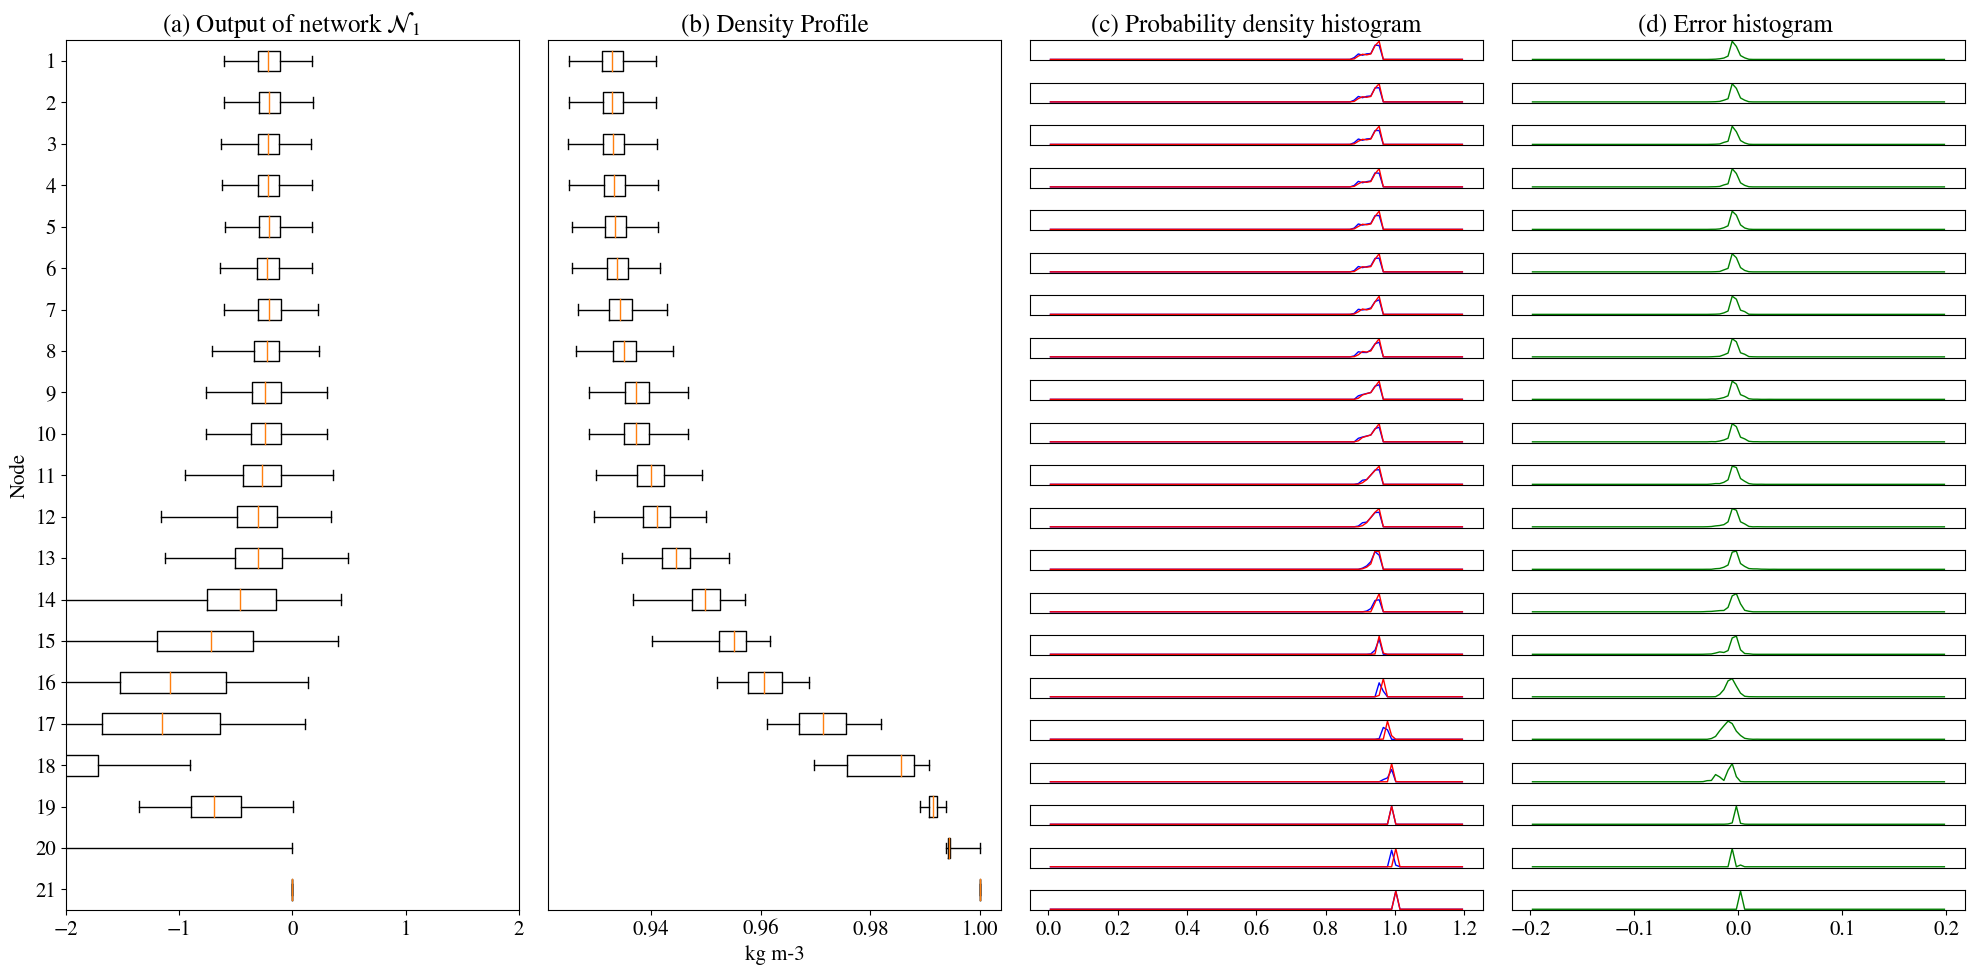

In [27]:
performance_sigma_point(model, x, valid_x, y, valid_y, k_mean, k_std, maxes)

## Predicting Diffusivity from Density

Predicting diffusivity from density would allow us to acquire diffusivity profiles for the Papa observational data.

To do this, we ran our own GOTM simulation using meteorological forcings from the OWS papa weather station. As shown above, the mixed layer depths reported by the sim do not match those from the calculated thresholds, and we're not sure which to trust.

However, assuming that the sim is at least internally consistent, we can still explore the prediction task.

In [16]:
from predict_diffusivity import (
    load_data,
    train,
    plot_predictions,
    evaluate_model,
    observational_to_dataset,
    predict_from_observations,
)

The sim data was generated on an 800 level, 1 meter resolution grid, at a 60s timestep and hourly outputs over a . The maximum reported mixed layer depth was never larger than 300, so we cropped the data to 300 meters deep. 

We ran sims in 2 year chunks and then recombined the data, covering 2011-2023. We include `density` `diffusivity` and `mld_depth` - see `process_sim_data.py` for more details.

In [17]:
ds = load_data()
ds['time']

<xarray.DataArray 'time' (time: 113952)> Size: 912kB
array(['2011-01-01T01:00:00.000000000', '2011-01-01T02:00:00.000000000',
       '2011-01-01T03:00:00.000000000', ..., '2023-12-31T22:00:00.000000000',
       '2023-12-31T23:00:00.000000000', '2024-01-01T00:00:00.000000000'],
      shape=(113952,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 912kB 2011-01-01T01:00:00 ... 2024-01-01

## Model Design & Training

The model we used is a fully connected feedforward neural network with two hidden layers of 512 units and ReLU activations, mapping a 305-dimensional input (300-profile + 5 aux features) to a 300-dimensional output profile.

The 5 aux features are: **mixed layer depth, sin(day of year), cos(day of year), sin(hour of day), cos(hour of day)**. These additional features were chosen to:
* provide a sharper "knee" where the mixed layer ends
* allow the network to learn seasonal and diurnal periodicity in the profiles.

Training improvements tailed off significantly after 6 epochs, and training takes 15s on my M3 Macbook Pro. 

In [18]:
depth = ds['depth'].values
model, test_loader = train(ds, epochs=6)

Epoch 1, Loss: 57.4077
Epoch 2, Loss: 46.1280
Epoch 3, Loss: 45.5481
Epoch 4, Loss: 45.0395
Epoch 5, Loss: 45.0024
Epoch 6, Loss: 44.5643
Saved training y_mean: 4.77e-03, y_std: 9.64e-03


In [19]:
evaluate_model(model, test_loader)

→ y_true mean: 0.0047762864 std: 0.014754568
→ y_pred mean: 0.0046357713 std: 0.01433525
→ MSE: 1.6042036804719828e-05
→ Var(y_true): 0.00021769729
→ R² from formula: 0.92631036
Evaluation Metrics:
  MSE:  0.000016
  MAE:  0.001395
  R²:   0.9263


After training, the model achieved an R2 value of ~.9, and we further verified performance by eyeballing a selection of plots from the test set.

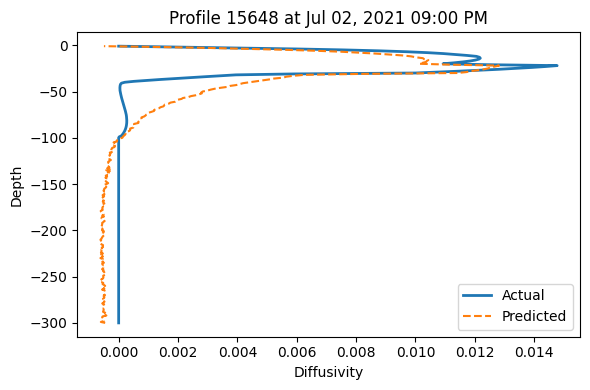

In [20]:
plot_predictions(model, test_loader, depth, index=15648)


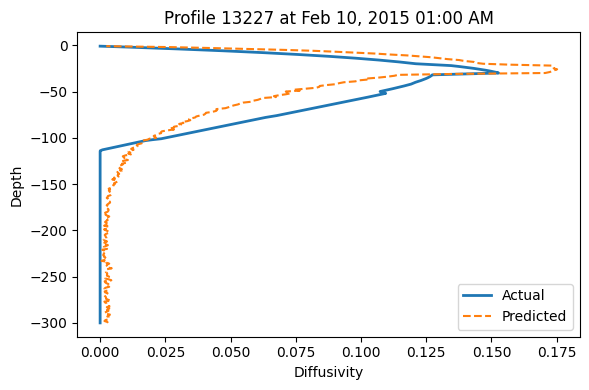

In [21]:
plot_predictions(model, test_loader, depth, index=13227)

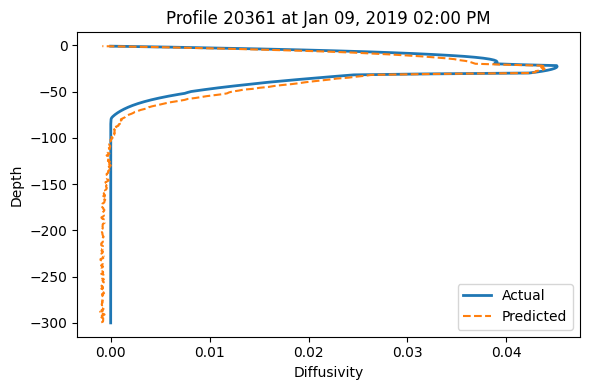

In [22]:
plot_predictions(model, test_loader, depth, index=20361)

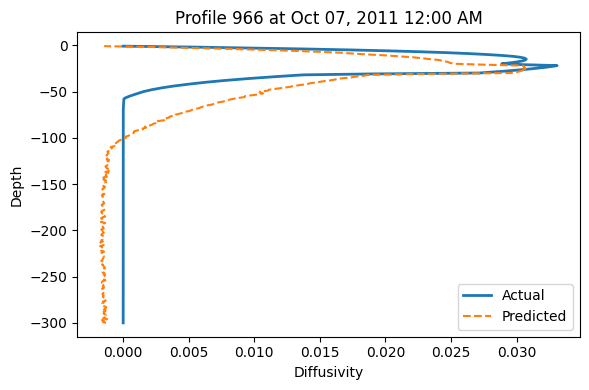

In [23]:
plot_predictions(model, test_loader, depth, index=966)

## Applying the Model to Observational Data

To make predictions based on the observational data, we first need to expand the density profiles from the 21 layers in the OWS Papa data, to the 300 which are expected by the model. We performed linear interpolation to expand the profiles to the desired resolution.

The predictions created from this method are bad, and we didn't have enough time to optimize them further. We applied gaussian filtering to smooth out some of the noise, which revealed profiles which look roughly physical.

The main issue we encountered is that the model is trained with normalized data - but since there is no validation set for the observational data, we can't normalize / denormalize the same way.

Furthermore, the real-world data is generally less smooth than the simulated data, and the model is not as good at handling discontinuities. We would like to investigate using hybrid / augmented data which noisier in future training.

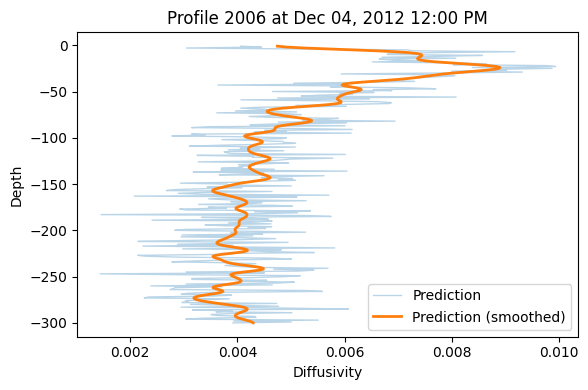

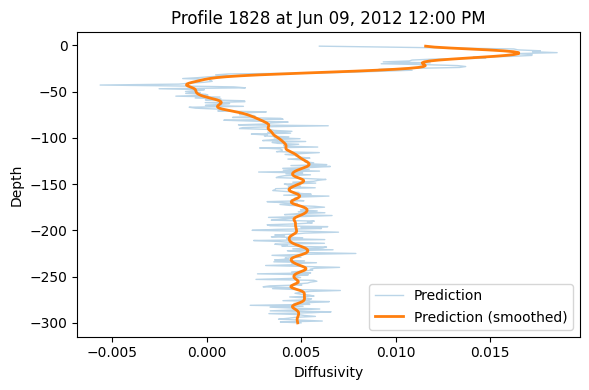

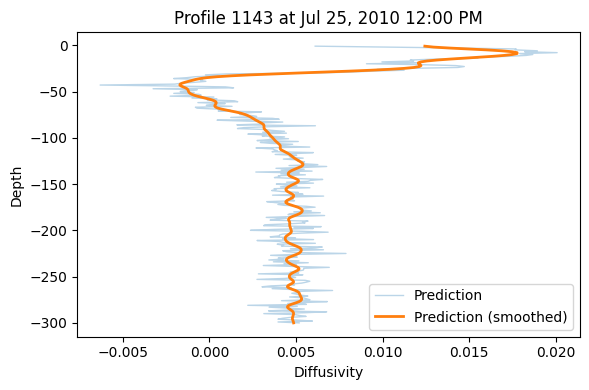

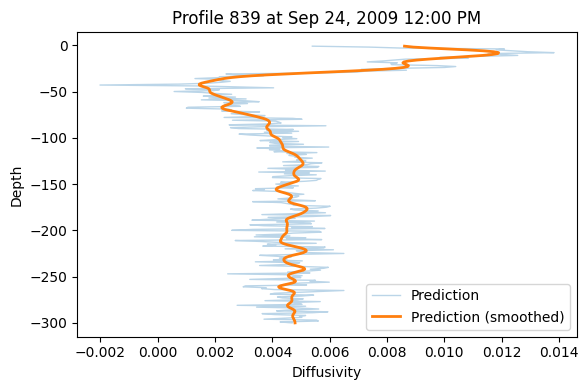

In [24]:
xr_dataset = observational_to_dataset('density_papa')
predict_from_observations(xr_dataset, model)

## Comparing the observational data variables to the input variables used in the paper:

- **Surface Temperature**: The paper’s model includes temperature as the only active tracer, affecting buoyancy and vertical mixing (the temperature comes from GOTM runs, where the initial surface temperature is set to 20°C ). On the other hand, observational sea surface temperature (SST) from Papa Station provides real-world validation for these modeled conditions.
- **Salinity**: In the paper, salinity is kept constant during simulations, meaning variations in ocean density arise solely from temperature and not from salinity differences. In contrast, Papa Station records salinity variations, which could influence density stratification in reality.
- **Surface Heat Flux (Radiation)**: The paper uses surface heat flux as a key input, with a range from −600 to 600 W/m² in N1 and up to ±2000 W/m² in N2. However, Papa Station has solar radiation and longwave radiation measurements that directly contribute to the net heat flux, both impacting ocean stratification and mixed layer depth.
- **Wind Speed & Surface Wind Stress**: The paper's simulations apply surface wind stress (friction velocity, u*), which influences vertical mixing and boundary layer depth. On the other hand, Papa Station records wind speed, which can be converted into wind stress for direct comparison with the study's inputs. (Convert wind speed (m/s) into wind stress (N/m²) using the bulk formula τ=ρa​*CD​*U^2)
- **Density & Boundary Layer Depth**: The paper models reference density at 1027 kg/m³ and diagnoses boundary layer depth based on vertical mixing. In contrast, Papa Station's density observations allow for real-world comparison of modeled and actual stratification.
- **Air Temperature**: In the paper, air temperature influences longwave radiation and sensible heat flux, which contribute to the overall surface heat flux affecting ocean stratification and vertical mixing. On the other hand, Papa Station directly records air temperature which can help validate the heat flux assumptions used in the study.
- **Barometric Pressure**: Although Papa Station measures barometric pressure, the paper does not explicitly use barometric pressure as a direct input, but pressure variations can influence wind stress and buoyancy forcing, which are key parameters in the model.
- **Rainfall (Precipitation)**: The paper assumes constant salinity, meaning rainfall and freshwater input are not directly considered. However, in reality, precipitation affects surface buoyancy flux and stratification by altering salinity and density. Thus, Papa Station’s rainfall data could provide insights into deviations from the model's simplified assumptions.


## Seasonality 




The surface ocean is influenced by mechanical forces from wind stress and tidal interactions with the seafloor, thermal processes driven by solar radiation and heat exchange with the atmosphere, and freshwater fluxes resulting from interactions with the atmosphere, sea ice, or adjacent landmasses. Seasonal variations driven by these factors impact temperature and density, which in turn influence ocean stratification and mixing.

### Why seasonality is important (changes in the mixed layer depth):
- **Summer**: during summer, increased solar radiation warms the surface ocean, making the water less dense and more stratified. This leads to a thinner mixed layer as heating inhibits turbulence. Also, the density profile of the upper ocean is more stratified (stronger vertical gradient) in summer due to the warming of the surface layer.
- **Winter**: during winter, cooling temperatures and mechanical forcing from winds and storms deepen the mixed layer by increasing the density of surface waters, causing convection and mixing with deeper waters. The mixed layer is thickest at the end of winter due to accumulated cooling and storm activity. Also, in winter, the density profile becomes more uniform as surface cooling and wind-driven mixing deepen the mixed layer, reducing stratification.


## Summary:

The notebook explores the use of neural networks to predict ocean surface boundary layer density profiles using observational data from Papa Station. The methodology follows Sane et al. (2023), focusing on parameterizing vertical mixing coefficients in the ocean surface boundary layer.

### Potential Advancements for Ocean Science & Climate Models:
By leveraging observational data and machine learning techniques, we aim to provide better estimates of density profiles, which can enhance climate models, leading to more accurate simulations of ocean circulation, heat transport, and biogeochemical cycles.

### Clarity for a Scientifically Trained Audience:

Density profiles are crucial for parameterizing ocean mixing in climate models because they directly influence the stability of the water column and the rates at which heat, salt, and other tracers are transported within the ocean. The vertical gradient of density (known as stratification), determines whether water masses mix easily or remain separated. Strong stratification (meaning large density differences between layers) suppresses vertical mixing, while weak stratification allows for more efficient mixing, which impacts factors such as heat storage, nutrient distribution, and the uptake of atmospheric carbon dioxide.  

In addition, Neural networks outperform traditional parameterizations because they can learn complex, nonlinear relationships from data, capturing small-scale turbulence and interactions that simple empirical models miss. For example, traditional methods rely on rule-based approximations, struggling with processes like internal waves and submesoscale mixing. In contrast, neural networks adapt dynamically to different ocean conditions, integrating diverse inputs to improve accuracy. By training on high-resolution simulations, they enhance subgrid-scale parameterizations in climate models, improving predictions of ocean mixing, heat transport, and circulation at a lower computational cost.


### Contribution Statment:
Sam and Azam clean Papa Station data (https://www.pmel.noaa.gov/ocs/data/disdel/). Azam create a NN which takes as inputs: (SST, SSS, and time) to predict density. Sam used the observational data from papa station and ploted the density overtime. Sam also managed to create a diffusivity profile based on the observational data. Ahinoam wrote up the explanations for the graph and the text for the data story, focusing on the climate science and seasonality, as well as explaining how the observational data variables relate to the input variables used in the paper. Azam and Sam carried out the computation for model evaluation. All team members contributed to the GitHub repository and prepared the presentation. All team members approve our work presented in our GitHub repository including this contribution statement.